# 04 — Quadtree 2D del cielo (Stellar Classification SDSS17)

> **Fase complementaria del playbook** — visualización espacial 2D de la densidad celeste.
>
> El quadtree subdivide el cielo en cuadrantes basados en densidad. Cada nodo agrega información sobre cuántos objetos hay y qué clase domina. El frontend (D3.js) consumirá el JSON exportado para renderizar el mapa interactivo.

## Definition of Done (Día 4)
- [ ] Quadtree implementado con `max_depth` y `min_count` configurables.
- [ ] Subdivisión recursiva basada en densidad (un cuadrante se divide si tiene >`min_count` objetos).
- [ ] Cada nodo expone: `id`, `depth`, `bounds`, `count`, `class_distribution`, `dominant_class`, `children`.
- [ ] Quadtree construido sobre el dataset limpio (99,999 filas, sin centinela `-9999`).
- [ ] Preview con matplotlib (rectángulos coloreados por clase dominante).
- [ ] JSON exportado a `frontend/public/data/quadtree.json`.
- [ ] `quadtree_summary.json` con estadísticas (nodos totales, hojas, profundidad real, balance).
- [ ] Suma de counts de las hojas == 99,999 (invariante).

## Imports y carga del dataset limpio

In [1]:
import json
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba

# Rutas
ROOT = Path('..').resolve()
DATA_PATH = ROOT / 'backend' / 'data' / 'star_classification.csv'
FRONTEND_DATA = ROOT / 'frontend' / 'public' / 'data'
DOCS_DIR = ROOT / 'docs'
FRONTEND_DATA.mkdir(parents=True, exist_ok=True)

# Parámetros del quadtree
MAX_DEPTH = 6           # 4^6 = 4096 nodos máximos a nivel hoja — manejable en D3.js
MIN_COUNT = 100         # No subdividir si un cuadrante tiene < 100 objetos
PHOTOMETRIC_BANDS = ['u', 'g', 'r', 'i', 'z']
CLASS_COLORS = {'GALAXY': '#3b82f6', 'STAR': '#fbbf24', 'QSO': '#a855f7'}

# Cargar dataset y limpiar centinelas (consistente con notebook 02)
df = pd.read_csv(DATA_PATH)
mask = (df[PHOTOMETRIC_BANDS] == -9999).any(axis=1)
df = df[~mask].copy()
print(f'Dataset cargado: {len(df):,} filas (post drop centinela)')
print(f'Bounds reales del dataset:')
print(f'  alpha (RA):  [{df["alpha"].min():.4f}, {df["alpha"].max():.4f}]')
print(f'  delta (DEC): [{df["delta"].min():.4f}, {df["delta"].max():.4f}]')

Dataset cargado: 99,999 filas (post drop centinela)
Bounds reales del dataset:
  alpha (RA):  [0.0055, 359.9998]
  delta (DEC): [-18.7853, 83.0005]


## Paso 1 — Definir el Quadtree

Estructura simple: cada nodo es un dict con `id, depth, bounds, count, class_distribution, dominant_class, children`. Subdivisión recursiva.

In [2]:
def build_quadtree(df, bounds, depth=0, max_depth=MAX_DEPTH, min_count=MIN_COUNT, node_id='0'):
    """
    Construye un quadtree recursivamente.

    Args:
        df: DataFrame con columnas 'alpha', 'delta', 'class' (debe estar filtrado al cuadrante actual).
        bounds: dict con 'alpha_min', 'alpha_max', 'delta_min', 'delta_max'.
        depth: profundidad actual.
        max_depth: profundidad máxima permitida.
        min_count: si count < min_count, no subdividir.
        node_id: identificador jerárquico ('0', '0-1', '0-1-3', ...).

    Returns:
        list[dict] — lista plana de nodos (incluye internos y hojas).
    """
    count = len(df)
    class_dist = df['class'].value_counts().to_dict()
    dominant_class = max(class_dist, key=class_dist.get) if class_dist else None

    nodes = []
    is_leaf = (depth >= max_depth) or (count <= min_count) or (count == 0)

    if is_leaf:
        nodes.append({
            'id': node_id,
            'depth': depth,
            'bounds': bounds,
            'count': int(count),
            'class_distribution': {k: int(v) for k, v in class_dist.items()},
            'dominant_class': dominant_class,
            'children': [],
            'is_leaf': True,
        })
        return nodes

    # Subdividir en 4 cuadrantes
    alpha_mid = (bounds['alpha_min'] + bounds['alpha_max']) / 2
    delta_mid = (bounds['delta_min'] + bounds['delta_max']) / 2

    children_ids = [f'{node_id}-{i}' for i in range(4)]
    nodes.append({
        'id': node_id,
        'depth': depth,
        'bounds': bounds,
        'count': int(count),
        'class_distribution': {k: int(v) for k, v in class_dist.items()},
        'dominant_class': dominant_class,
        'children': children_ids,
        'is_leaf': False,
    })

    # Cuadrante 0: bottom-left (alpha_min..alpha_mid, delta_min..delta_mid)
    # Cuadrante 1: bottom-right
    # Cuadrante 2: top-left
    # Cuadrante 3: top-right
    quadrants = [
        {'alpha_min': bounds['alpha_min'], 'alpha_max': alpha_mid,
         'delta_min': bounds['delta_min'], 'delta_max': delta_mid},
        {'alpha_min': alpha_mid, 'alpha_max': bounds['alpha_max'],
         'delta_min': bounds['delta_min'], 'delta_max': delta_mid},
        {'alpha_min': bounds['alpha_min'], 'alpha_max': alpha_mid,
         'delta_min': delta_mid, 'delta_max': bounds['delta_max']},
        {'alpha_min': alpha_mid, 'alpha_max': bounds['alpha_max'],
         'delta_min': delta_mid, 'delta_max': bounds['delta_max']},
    ]

    for child_id, child_bounds in zip(children_ids, quadrants):
        # Filtrar filas que caen en este cuadrante
        # Importante: incluyente en min, excluyente en max (excepto borde superior)
        in_quadrant = (
            (df['alpha'] >= child_bounds['alpha_min']) &
            (df['alpha'] < child_bounds['alpha_max'] if child_bounds['alpha_max'] < bounds['alpha_max']
             else df['alpha'] <= child_bounds['alpha_max']) &
            (df['delta'] >= child_bounds['delta_min']) &
            (df['delta'] < child_bounds['delta_max'] if child_bounds['delta_max'] < bounds['delta_max']
             else df['delta'] <= child_bounds['delta_max'])
        )
        child_df = df[in_quadrant]
        nodes.extend(build_quadtree(child_df, child_bounds, depth + 1, max_depth, min_count, child_id))

    return nodes

print('Quadtree builder definido. Parámetros:')
print(f'  MAX_DEPTH = {MAX_DEPTH}')
print(f'  MIN_COUNT = {MIN_COUNT}')

Quadtree builder definido. Parámetros:
  MAX_DEPTH = 6
  MIN_COUNT = 100


## Paso 2 — Construir el quadtree sobre el dataset completo

Bounds: usamos el rango real del dataset, no el cielo completo. SDSS17 cubre principalmente hemisferio norte.

In [3]:
# Bounds con pequeño margen para incluir extremos
ROOT_BOUNDS = {
    'alpha_min': 0.0,
    'alpha_max': 360.0,
    'delta_min': float(df['delta'].min()) - 0.001,
    'delta_max': float(df['delta'].max()) + 0.001,
}

print(f'Bounds raíz: {ROOT_BOUNDS}')

# Construir
import time
start = time.time()
nodes = build_quadtree(df[['alpha', 'delta', 'class']], ROOT_BOUNDS)
elapsed = time.time() - start

print(f'\nQuadtree construido en {elapsed:.2f}s')
print(f'  Total nodos: {len(nodes)}')
print(f'  Hojas:       {sum(1 for n in nodes if n["is_leaf"])}')
print(f'  Internos:    {sum(1 for n in nodes if not n["is_leaf"])}')

max_depth_real = max(n['depth'] for n in nodes)
print(f'  Profundidad máxima real: {max_depth_real} (configurada: {MAX_DEPTH})')

# Invariante crítico: suma de counts de las hojas == total dataset
leaf_sum = sum(n['count'] for n in nodes if n['is_leaf'])
print(f'\nInvariante: sum(count) de hojas = {leaf_sum:,} | dataset = {len(df):,}')
assert leaf_sum == len(df), f'Mismatch: hojas={leaf_sum}, dataset={len(df)}'
print('✓ Invariante OK — todas las filas están representadas en exactamente una hoja')

Bounds raíz: {'alpha_min': 0.0, 'alpha_max': 360.0, 'delta_min': -18.7863280771825, 'delta_max': 83.00151858898}



Quadtree construido en 0.60s
  Total nodos: 1973
  Hojas:       1480
  Internos:    493
  Profundidad máxima real: 6 (configurada: 6)

Invariante: sum(count) de hojas = 99,999 | dataset = 99,999
✓ Invariante OK — todas las filas están representadas en exactamente una hoja


## Paso 3 — Estadísticas del quadtree por profundidad

In [4]:
depth_stats = Counter(n['depth'] for n in nodes)
leaf_stats = Counter(n['depth'] for n in nodes if n['is_leaf'])

print('Distribución de nodos por profundidad:')
print(f'  {"Depth":<6} {"Total":<8} {"Hojas":<8} {"Internos":<10}')
for d in sorted(depth_stats.keys()):
    total = depth_stats[d]
    leaves = leaf_stats.get(d, 0)
    internal = total - leaves
    print(f'  {d:<6} {total:<8} {leaves:<8} {internal:<10}')

# Distribución de counts en las hojas
leaf_counts = [n['count'] for n in nodes if n['is_leaf']]
print(f'\nCounts en hojas (n={len(leaf_counts)}):')
print(f'  min: {min(leaf_counts)}')
print(f'  max: {max(leaf_counts)}')
print(f'  media: {np.mean(leaf_counts):.1f}')
print(f'  mediana: {np.median(leaf_counts):.1f}')

# Hojas vacías (cuadrantes del cielo sin objetos)
empty_leaves = sum(1 for n in nodes if n['is_leaf'] and n['count'] == 0)
print(f'\nHojas vacías (sin objetos): {empty_leaves} ({empty_leaves/len(leaf_counts)*100:.1f}%)')

Distribución de nodos por profundidad:
  Depth  Total    Hojas    Internos  
  0      1        0        1         
  1      4        0        4         
  2      16       1        15        
  3      60       19       41        
  4      164      49       115       
  5      460      143      317       
  6      1268     1268     0         

Counts en hojas (n=1480):
  min: 0
  max: 595
  media: 67.6
  mediana: 55.0

Hojas vacías (sin objetos): 66 (4.5%)


## Paso 4 — Preview visual con matplotlib

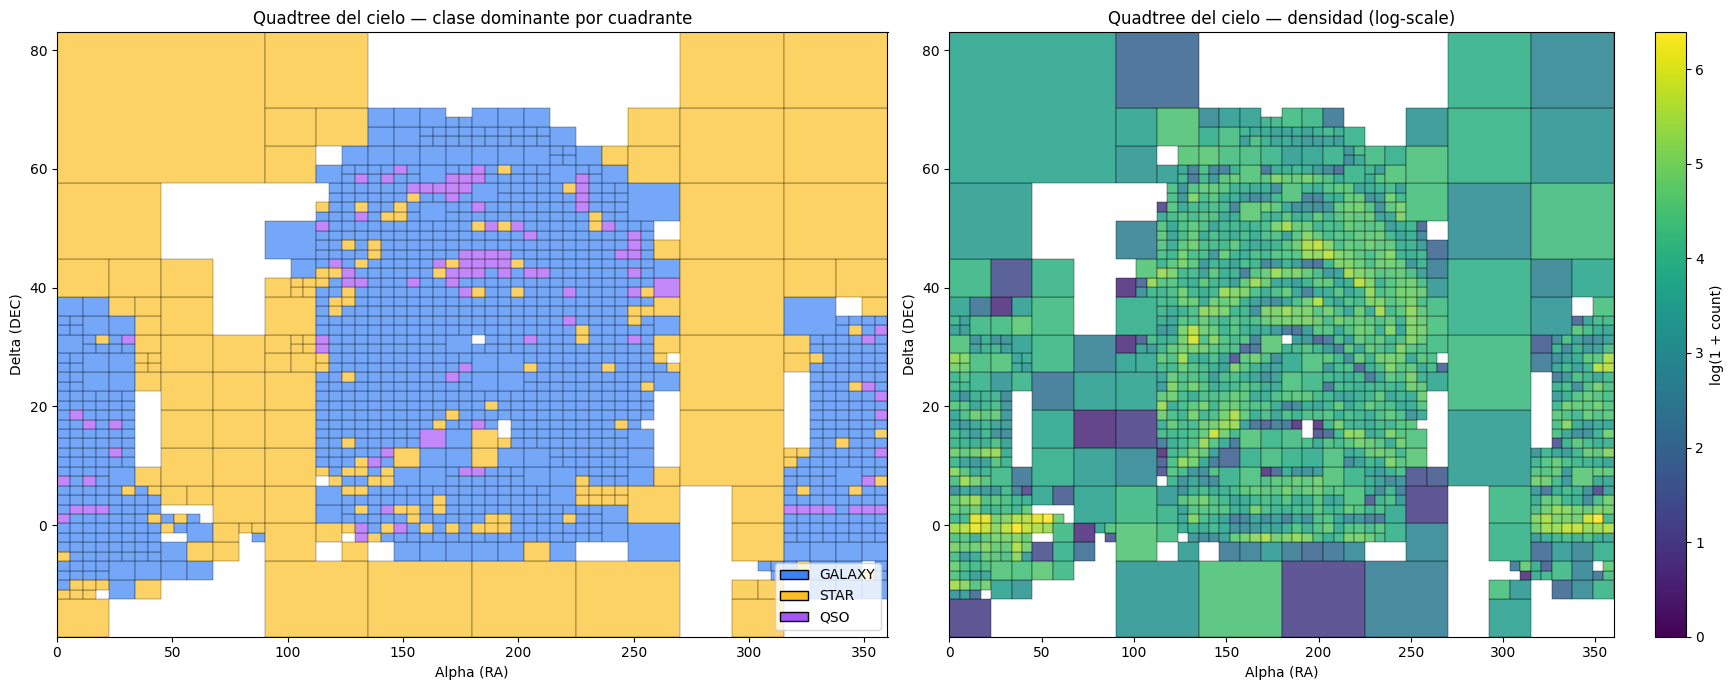

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: rectángulos coloreados por clase dominante
ax = axes[0]
for n in nodes:
    if not n['is_leaf'] or n['count'] == 0:
        continue
    b = n['bounds']
    color = CLASS_COLORS.get(n['dominant_class'], 'lightgray')
    rect = patches.Rectangle(
        (b['alpha_min'], b['delta_min']),
        b['alpha_max'] - b['alpha_min'],
        b['delta_max'] - b['delta_min'],
        linewidth=0.3, edgecolor='black', facecolor=color, alpha=0.7,
    )
    ax.add_patch(rect)
ax.set_xlim(ROOT_BOUNDS['alpha_min'], ROOT_BOUNDS['alpha_max'])
ax.set_ylim(ROOT_BOUNDS['delta_min'], ROOT_BOUNDS['delta_max'])
ax.set_xlabel('Alpha (RA)')
ax.set_ylabel('Delta (DEC)')
ax.set_title('Quadtree del cielo — clase dominante por cuadrante')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=k) for k, c in CLASS_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right')

# Plot 2: heatmap de densidad (log-scale)
ax = axes[1]
max_count = max((n['count'] for n in nodes if n['is_leaf']), default=1)
for n in nodes:
    if not n['is_leaf'] or n['count'] == 0:
        continue
    b = n['bounds']
    intensity = np.log1p(n['count']) / np.log1p(max_count)
    rect = patches.Rectangle(
        (b['alpha_min'], b['delta_min']),
        b['alpha_max'] - b['alpha_min'],
        b['delta_max'] - b['delta_min'],
        linewidth=0.3, edgecolor='black',
        facecolor=plt.cm.viridis(intensity), alpha=0.85,
    )
    ax.add_patch(rect)
ax.set_xlim(ROOT_BOUNDS['alpha_min'], ROOT_BOUNDS['alpha_max'])
ax.set_ylim(ROOT_BOUNDS['delta_min'], ROOT_BOUNDS['delta_max'])
ax.set_xlabel('Alpha (RA)')
ax.set_ylabel('Delta (DEC)')
ax.set_title('Quadtree del cielo — densidad (log-scale)')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                           norm=plt.Normalize(vmin=0, vmax=np.log1p(max_count)))
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('log(1 + count)')

plt.tight_layout()
plt.show()

## Paso 5 — Exportar JSON para el frontend

In [6]:
quadtree_payload = {
    'metadata': {
        'generated_at': datetime.utcnow().isoformat() + 'Z',
        'dataset_rows': len(df),
        'max_depth': MAX_DEPTH,
        'min_count': MIN_COUNT,
        'feature_x': 'alpha',
        'feature_y': 'delta',
    },
    'bounds': ROOT_BOUNDS,
    'stats': {
        'total_nodes': len(nodes),
        'leaves': sum(1 for n in nodes if n['is_leaf']),
        'internal': sum(1 for n in nodes if not n['is_leaf']),
        'empty_leaves': int(empty_leaves),
        'max_depth_real': int(max_depth_real),
    },
    'nodes': nodes,
}

OUTPUT = FRONTEND_DATA / 'quadtree.json'
OUTPUT.write_text(json.dumps(quadtree_payload))
size_kb = OUTPUT.stat().st_size / 1024
print(f'✓ quadtree.json exportado: {OUTPUT} ({size_kb:.1f} KB)')
if size_kb > 5_000:
    print(f'  ⚠ Archivo grande ({size_kb:.1f}KB) — considerar reducir MAX_DEPTH si el frontend laggea')
else:
    print(f'  ✓ Tamaño OK para servir desde frontend (<5MB)')

✓ quadtree.json exportado: /Users/alejandromarcelo/Desktop/PROYECTOS_2026/stellar-classifier/frontend/public/data/quadtree.json (582.2 KB)
  ✓ Tamaño OK para servir desde frontend (<5MB)


## Paso 6 — Generar quadtree_summary.json

In [7]:
summary = {
    'timestamp': datetime.utcnow().isoformat() + 'Z',
    'parameters': {
        'max_depth': MAX_DEPTH,
        'min_count': MIN_COUNT,
    },
    'dataset': {
        'rows_input': len(df),
        'bounds': ROOT_BOUNDS,
    },
    'output': {
        'path': str(OUTPUT.relative_to(ROOT)),
        'size_kb': round(size_kb, 2),
    },
    'tree': {
        'total_nodes': len(nodes),
        'leaves': sum(1 for n in nodes if n['is_leaf']),
        'internal': sum(1 for n in nodes if not n['is_leaf']),
        'empty_leaves': int(empty_leaves),
        'max_depth_real': int(max_depth_real),
        'nodes_per_depth': {str(d): depth_stats[d] for d in sorted(depth_stats.keys())},
        'leaf_count_min': int(min(leaf_counts)),
        'leaf_count_max': int(max(leaf_counts)),
        'leaf_count_median': float(np.median(leaf_counts)),
    },
    'invariant_check': {
        'sum_leaves_eq_rows': bool(leaf_sum == len(df)),
        'leaf_sum': leaf_sum,
        'dataset_rows': len(df),
    },
    'decisions': [
        f'MAX_DEPTH={MAX_DEPTH}, MIN_COUNT={MIN_COUNT} para mantener JSON manejable (<5MB).',
        'Bounds: alpha=[0,360], delta=[dataset.min(), dataset.max()] (SDSS17 no cubre cielo sur completo).',
        'Quadtree construido sobre dataset limpio (99,999 filas, sin centinela -9999).',
        'Subdivisión: 4 cuadrantes por nodo, balanceado geométricamente (no por densidad).',
        'Hojas vacías se mantienen para que el frontend pueda dibujar el grid completo.',
    ],
}

SUMMARY_PATH = DOCS_DIR / 'quadtree_summary.json'
SUMMARY_PATH.write_text(json.dumps(summary, indent=2))
print(f'✓ quadtree_summary.json guardado en {SUMMARY_PATH}')
print(json.dumps(summary, indent=2))

✓ quadtree_summary.json guardado en /Users/alejandromarcelo/Desktop/PROYECTOS_2026/stellar-classifier/docs/quadtree_summary.json
{
  "timestamp": "2026-05-27T15:42:16.848167Z",
  "parameters": {
    "max_depth": 6,
    "min_count": 100
  },
  "dataset": {
    "rows_input": 99999,
    "bounds": {
      "alpha_min": 0.0,
      "alpha_max": 360.0,
      "delta_min": -18.7863280771825,
      "delta_max": 83.00151858898
    }
  },
  "output": {
    "path": "frontend/public/data/quadtree.json",
    "size_kb": 582.2
  },
  "tree": {
    "total_nodes": 1973,
    "leaves": 1480,
    "internal": 493,
    "empty_leaves": 66,
    "max_depth_real": 6,
    "nodes_per_depth": {
      "0": 1,
      "1": 4,
      "2": 16,
      "3": 60,
      "4": 164,
      "5": 460,
      "6": 1268
    },
    "leaf_count_min": 0,
    "leaf_count_max": 595,
    "leaf_count_median": 55.0
  },
  "invariant_check": {
    "sum_leaves_eq_rows": true,
    "leaf_sum": 99999,
    "dataset_rows": 99999
  },
  "decisions": [
  

## Resumen

Notebook 04 terminado:
- ✅ Quadtree construido sobre 99,999 filas.
- ✅ Invariante validado (sum hojas == dataset).
- ✅ Preview matplotlib (clase dominante + densidad).
- ✅ JSON exportado a `frontend/public/data/quadtree.json`.

**Siguiente**: notebook `05_octree_3d.ipynb` (octree 3D + cKDTree productivo para k-NN del backend), o pasar al Día 5 (FastAPI) según orden del plan.

**Nota**: el plan tiene Día 5 (FastAPI con `/api/predict`) antes que Día 6 (octree). Cumplir el orden del plan.